# Proyecto Final - Analisis de Tiempo Dedicado a Lectura

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

### Carga de datos

In [2]:
df = pd.read_csv('conjunto_de_datos_enut_2019_csv/conjunto_de_datos_tmodulo_enut_2019/conjunto_de_datos/conjunto_de_datos_tmodulo_enut_2019.csv')

In [3]:
columns = ['CVE_ENT', 'SEXO', 'EDAD_V', 'TLOC', 'NIV', 'GRA', 
           'P6_22_4', 'P6_22A_4_1', 'P6_22A_4_2', 'P6_22A_4_3', 'P6_22A_4_4',]

In [4]:
df = df[columns]

In [5]:
print(df.info())
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 71404 entries, 0 to 71403
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   CVE_ENT     71404 non-null  int64  
 1   SEXO        71404 non-null  int64  
 2   EDAD_V      71404 non-null  int64  
 3   TLOC        71404 non-null  int64  
 4   NIV         71404 non-null  int64  
 5   GRA         71404 non-null  int64  
 6   P6_22_4     71404 non-null  int64  
 7   P6_22A_4_1  16912 non-null  float64
 8   P6_22A_4_2  16912 non-null  float64
 9   P6_22A_4_3  16912 non-null  float64
 10  P6_22A_4_4  16912 non-null  float64
dtypes: float64(4), int64(7)
memory usage: 6.0 MB
None


,CVE_ENT,SEXO,EDAD_V,TLOC,NIV,GRA,P6_22_4,P6_22A_4_1,P6_22A_4_2,P6_22A_4_3,P6_22A_4_4
0,1,2,37,1,3,3,2,NaN,NaN,NaN,NaN
1,1,1,67,1,8,2,2,NaN,NaN,NaN,NaN
2,1,2,60,1,3,3,1,0.0,50.0,0.0,20.0
3,1,1,29,1,8,5,1,0.0,0.0,1.0,0.0
4,1,1,69,1,2,3,2,NaN,NaN,NaN,NaN


### Seleccion de variales de interes

In [6]:
print(df.info())
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 71404 entries, 0 to 71403
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   CVE_ENT     71404 non-null  int64  
 1   SEXO        71404 non-null  int64  
 2   EDAD_V      71404 non-null  int64  
 3   TLOC        71404 non-null  int64  
 4   NIV         71404 non-null  int64  
 5   GRA         71404 non-null  int64  
 6   P6_22_4     71404 non-null  int64  
 7   P6_22A_4_1  16912 non-null  float64
 8   P6_22A_4_2  16912 non-null  float64
 9   P6_22A_4_3  16912 non-null  float64
 10  P6_22A_4_4  16912 non-null  float64
dtypes: float64(4), int64(7)
memory usage: 6.0 MB
None


,CVE_ENT,SEXO,EDAD_V,TLOC,NIV,GRA,P6_22_4,P6_22A_4_1,P6_22A_4_2,P6_22A_4_3,P6_22A_4_4
0,1,2,37,1,3,3,2,NaN,NaN,NaN,NaN
1,1,1,67,1,8,2,2,NaN,NaN,NaN,NaN
2,1,2,60,1,3,3,1,0.0,50.0,0.0,20.0
3,1,1,29,1,8,5,1,0.0,0.0,1.0,0.0
4,1,1,69,1,2,3,2,NaN,NaN,NaN,NaN


### Reemplazar códigos con descripciones de catálogos

In [7]:
# Ruta base de los catálogos
catalogos_path = 'conjunto_de_datos_enut_2019_csv/conjunto_de_datos_tmodulo_enut_2019/catalogos'

# Columnas con catálogos
columnas_con_catalogo = ['CVE_ENT', 'SEXO', 'TLOC', 'NIV', 'P6_22_4']

# Reemplazar valores usando los catálogos
for col in columnas_con_catalogo:
    catalogo_file = os.path.join(catalogos_path, f'{col.lower()}.csv')
    
    if os.path.exists(catalogo_file):
        # Leer catálogo
        catalogo = pd.read_csv(catalogo_file)
        
        # Crear diccionario de mapeo
        mapeo = dict(zip(catalogo['cve'], catalogo['descrip']))
        
        # Reemplazar valores en el dataframe
        df[col] = df[col].map(mapeo)
        
        print(f"✓ Columna '{col}' reemplazada con catálogo '{col.lower()}.csv'")
    else:
        print(f"✗ No se encontró el archivo '{col.lower()}.csv'")

✓ Columna 'CVE_ENT' reemplazada con catálogo 'cve_ent.csv'
✓ Columna 'SEXO' reemplazada con catálogo 'sexo.csv'
✓ Columna 'TLOC' reemplazada con catálogo 'tloc.csv'
✓ Columna 'NIV' reemplazada con catálogo 'niv.csv'
✓ Columna 'P6_22_4' reemplazada con catálogo 'p6_22_4.csv'


### Renombrar columnas

In [8]:
columns_mapping = {
    'CVE_ENT': 'clave_entidad',
    'SEXO': 'sexo',
    'EDAD_V': 'edad',
    'TLOC': 'tamaño_localidad',
    'NIV': 'nivel_educativo',
    'GRA': 'grado_maximo_aprobado',
    'P6_22_4': 'ha_leido',
    'P6_22A_4_1': 'horas_lunes_viernes',
    'P6_22A_4_2': 'minutos_lunes_viernes',
    'P6_22A_4_3': 'horas_sabado_domingo',
    'P6_22A_4_4': 'minutos_sabado_domingo',
}

df.rename(columns=columns_mapping, inplace=True)

In [9]:
print(df.info())
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 71404 entries, 0 to 71403
Data columns (total 11 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   clave_entidad           71404 non-null  object 
 1   sexo                    71404 non-null  object 
 2   edad                    71404 non-null  int64  
 3   tamaño_localidad        71404 non-null  object 
 4   nivel_educativo         71404 non-null  object 
 5   grado_maximo_aprobado   71404 non-null  int64  
 6   ha_leido                71404 non-null  object 
 7   horas_lunes_viernes     16912 non-null  float64
 8   minutos_lunes_viernes   16912 non-null  float64
 9   horas_sabado_domingo    16912 non-null  float64
 10  minutos_sabado_domingo  16912 non-null  float64
dtypes: float64(4), int64(2), object(5)
memory usage: 6.0+ MB
None


,clave_entidad,sexo,edad,tamaño_localidad,nivel_educativo,grado_maximo_aprobado,ha_leido,horas_lunes_viernes,minutos_lunes_viernes,horas_sabado_domingo,minutos_sabado_domingo
0,Aguascalientes,Mujer,37,Localidades con 100 000 y más habitantes,Secundaria,3,No,NaN,NaN,NaN,NaN
1,Aguascalientes,Hombre,67,Localidades con 100 000 y más habitantes,Licenciatura o ingeniería (profesional),2,No,NaN,NaN,NaN,NaN
2,Aguascalientes,Mujer,60,Localidades con 100 000 y más habitantes,Secundaria,3,Sí,0.0,50.0,0.0,20.0
3,Aguascalientes,Hombre,29,Localidades con 100 000 y más habitantes,Licenciatura o ingeniería (profesional),5,Sí,0.0,0.0,1.0,0.0
4,Aguascalientes,Hombre,69,Localidades con 100 000 y más habitantes,Primaria,3,No,NaN,NaN,NaN,NaN


### Analisis exploratorio de datos (EDA)

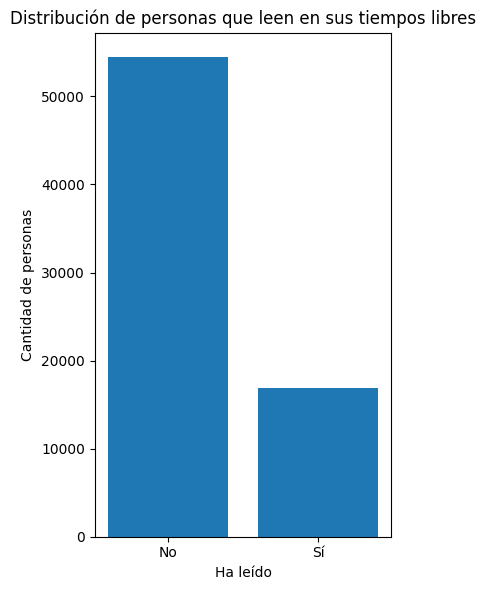

In [10]:
plt.figure(figsize=(4, 6))
plt.bar(df['ha_leido'].value_counts().index, df['ha_leido'].value_counts().values)
plt.title('Distribución de personas que leen en sus tiempos libres')
plt.xlabel('Ha leído')
plt.ylabel('Cantidad de personas')
plt.tight_layout()
plt.show()

In [11]:
df_lectores = df[df['ha_leido'] == 'Sí']
print(f"De las {len(df)} personas encuestadas, {len(df_lectores)} han leído en su tiempo libre, lo cual representa el {len(df_lectores) / len(df) * 100:.2f}% del total.")

De las 71404 personas encuestadas, 16912 han leído en su tiempo libre, lo cual representa el 23.68% del total.


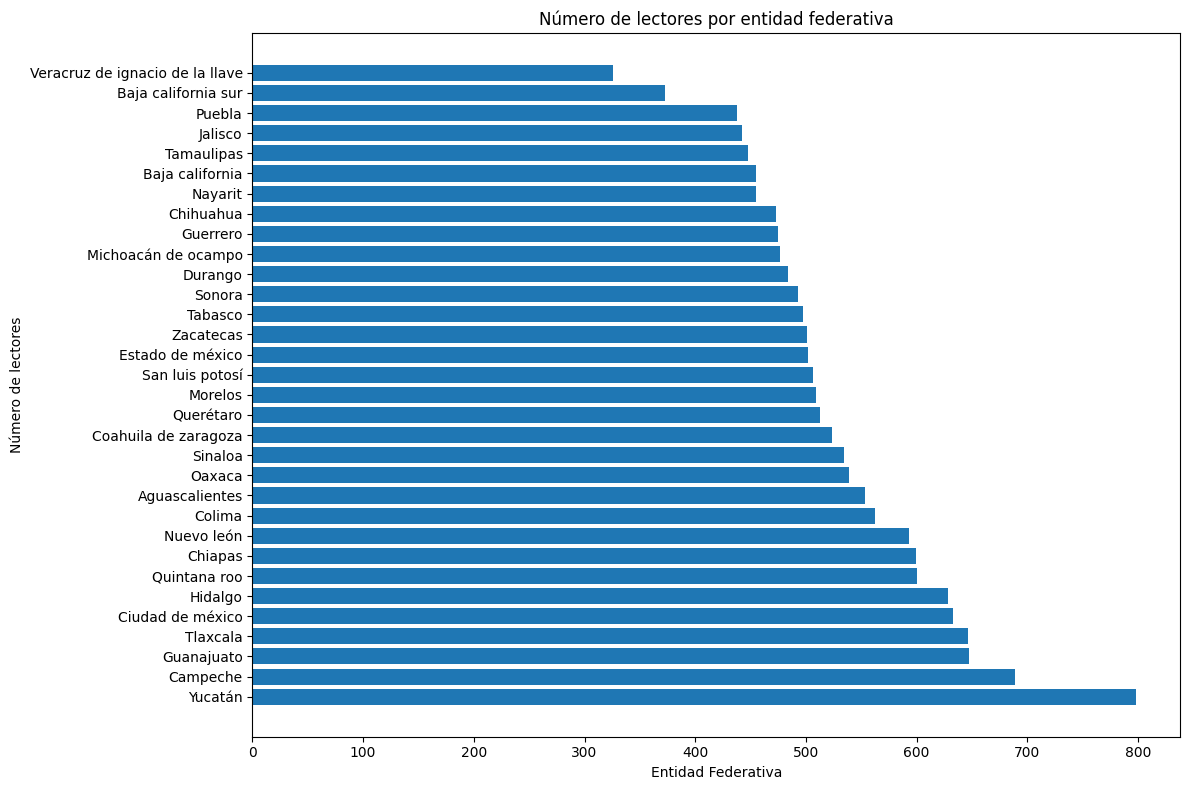

LECTORES POR ENTIDAD FEDERATIVA

Los 3 estados con más lectores:
['Yucatán', 'Campeche', 'Guanajuato']

Los 3 estados con menos lectores:
['Veracruz de ignacio de la llave', 'Baja california sur', 'Puebla']


In [12]:
# Lectores por entidad federativa
plt.figure(figsize=(12, 8))
plt.barh(df_lectores['clave_entidad'].value_counts().index, df_lectores['clave_entidad'].value_counts().values)
plt.title('Número de lectores por entidad federativa')
plt.xlabel('Entidad Federativa')
plt.ylabel('Número de lectores')
plt.tight_layout()
plt.show()

# Agrupacion por entidad federativa y conteo de lectores
lectores_por_entidad = df_lectores.groupby('clave_entidad').size().reset_index(name='numero_lectores')
top3_lectores = lectores_por_entidad.sort_values(by='numero_lectores', ascending=False).head(3)['clave_entidad'].tolist()
bottom3_lectores = lectores_por_entidad.sort_values(by='numero_lectores', ascending=True).head(3)['clave_entidad'].tolist()

print('LECTORES POR ENTIDAD FEDERATIVA')
print()
print('Los 3 estados con más lectores:')
print(top3_lectores)
print()
print('Los 3 estados con menos lectores:')
print(bottom3_lectores)

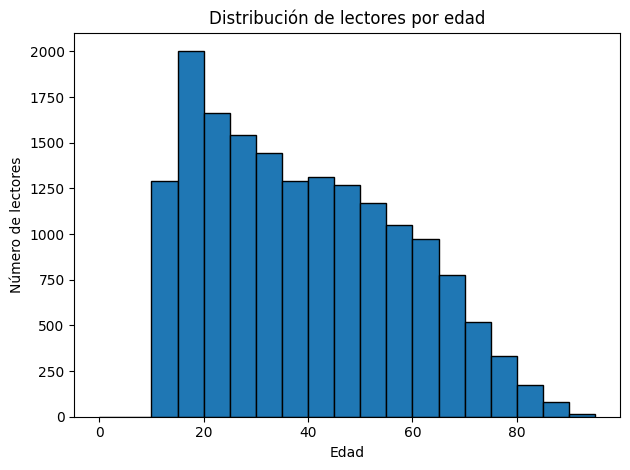

In [13]:
# Distribucion por edades
plt.hist(df_lectores['edad'], bins=range(0, 100, 5), edgecolor='black')
plt.title('Distribución de lectores por edad')
plt.xlabel('Edad')
plt.ylabel('Número de lectores')
plt.tight_layout()
plt.show()

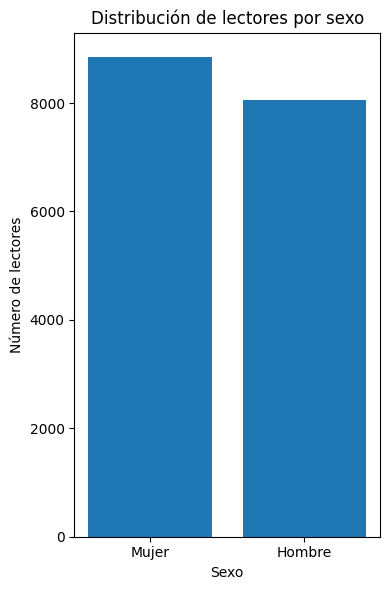

In [14]:
# Conteo por sexo
plt.figure(figsize=(4, 6))
plt.bar(df_lectores['sexo'].value_counts().index, df_lectores['sexo'].value_counts().values)
plt.title('Distribución de lectores por sexo')
plt.xlabel('Sexo')
plt.ylabel('Número de lectores')
plt.tight_layout()
plt.show()

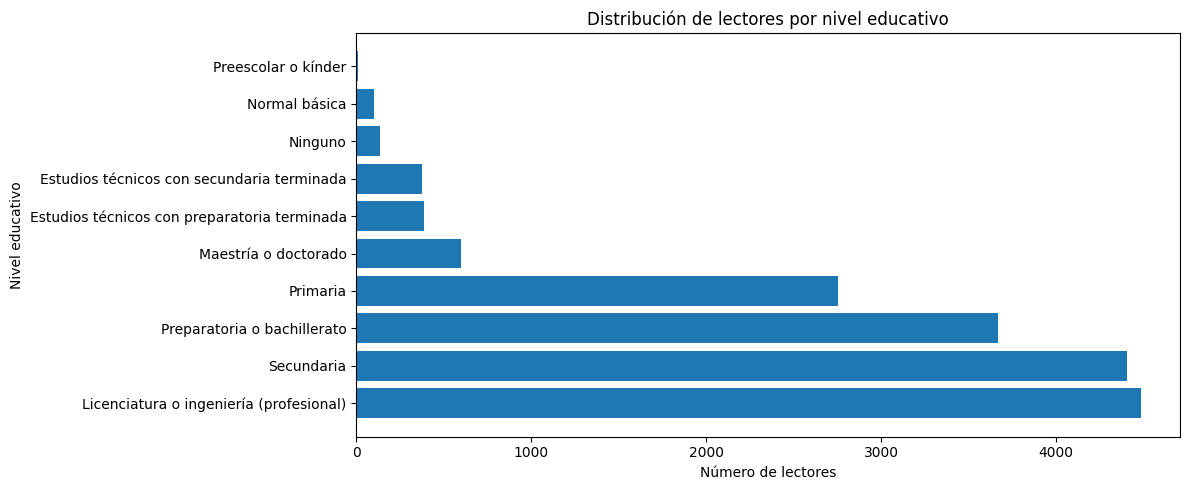

In [15]:
# Nivel educativo de los lectores
plt.figure(figsize=(12, 5))
plt.barh(df_lectores['nivel_educativo'].value_counts().index, df_lectores['nivel_educativo'].value_counts().values)
plt.title('Distribución de lectores por nivel educativo')
plt.xlabel('Número de lectores')
plt.ylabel('Nivel educativo')
plt.tight_layout()
plt.show()

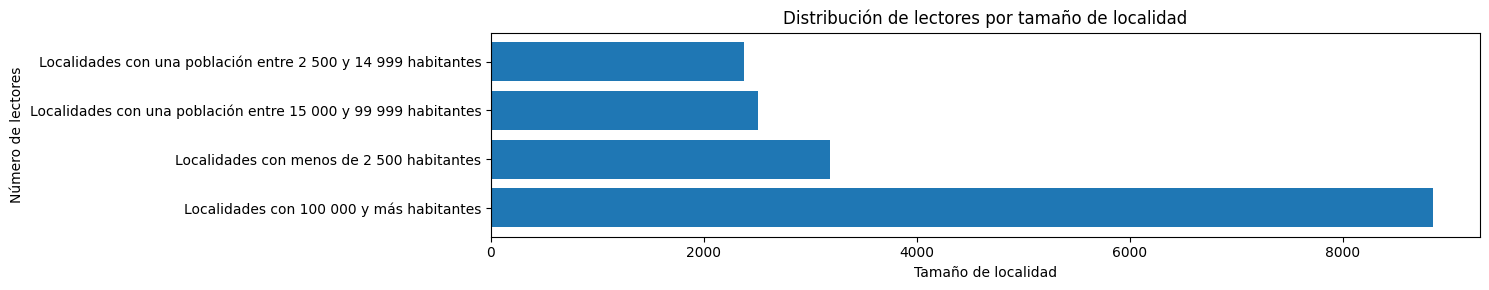

In [16]:
# Tamaño de localidad de los lectores
plt.figure(figsize=(15, 3))
plt.barh(df_lectores['tamaño_localidad'].value_counts().index, df_lectores['tamaño_localidad'].value_counts().values)
plt.title('Distribución de lectores por tamaño de localidad')
plt.xlabel('Tamaño de localidad')
plt.ylabel('Número de lectores')
plt.tight_layout()
plt.show()

In [17]:
df_lectores['tiempo_total'] = \
    df_lectores['horas_lunes_viernes'] * 60 + df_lectores['minutos_lunes_viernes'] + \
    df_lectores['horas_sabado_domingo'] * 60 + df_lectores['minutos_sabado_domingo']
    
print(df_lectores.info())
df_lectores.head()

<class 'pandas.core.frame.DataFrame'>
Index: 16912 entries, 2 to 71400
Data columns (total 12 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   clave_entidad           16912 non-null  object 
 1   sexo                    16912 non-null  object 
 2   edad                    16912 non-null  int64  
 3   tamaño_localidad        16912 non-null  object 
 4   nivel_educativo         16912 non-null  object 
 5   grado_maximo_aprobado   16912 non-null  int64  
 6   ha_leido                16912 non-null  object 
 7   horas_lunes_viernes     16912 non-null  float64
 8   minutos_lunes_viernes   16912 non-null  float64
 9   horas_sabado_domingo    16912 non-null  float64
 10  minutos_sabado_domingo  16912 non-null  float64
 11  tiempo_total            16912 non-null  float64
dtypes: float64(5), int64(2), object(5)
memory usage: 1.7+ MB
None


/tmp/ipykernel_12213/2422241045.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_lectores['tiempo_total'] = \


,clave_entidad,sexo,edad,tamaño_localidad,nivel_educativo,grado_maximo_aprobado,ha_leido,horas_lunes_viernes,minutos_lunes_viernes,horas_sabado_domingo,minutos_sabado_domingo,tiempo_total
2,Aguascalientes,Mujer,60,Localidades con 100 000 y más habitantes,Secundaria,3,Sí,0.0,50.0,0.0,20.0,70.0
3,Aguascalientes,Hombre,29,Localidades con 100 000 y más habitantes,Licenciatura o ingeniería (profesional),5,Sí,0.0,0.0,1.0,0.0,60.0
5,Aguascalientes,Mujer,68,Localidades con 100 000 y más habitantes,Primaria,6,Sí,10.0,0.0,0.0,0.0,600.0
6,Aguascalientes,Mujer,62,Localidades con 100 000 y más habitantes,Primaria,6,Sí,1.0,0.0,1.0,0.0,120.0
9,Aguascalientes,Hombre,71,Localidades con 100 000 y más habitantes,Primaria,6,Sí,5.0,0.0,0.0,0.0,300.0


In [18]:
df_lectores["tiempo_total"].describe()

count    16912.000000
mean       202.358739
std        228.930529
min          1.000000
25%         60.000000
50%        140.000000
75%        240.000000
max       4200.000000
Name: tiempo_total, dtype: float64

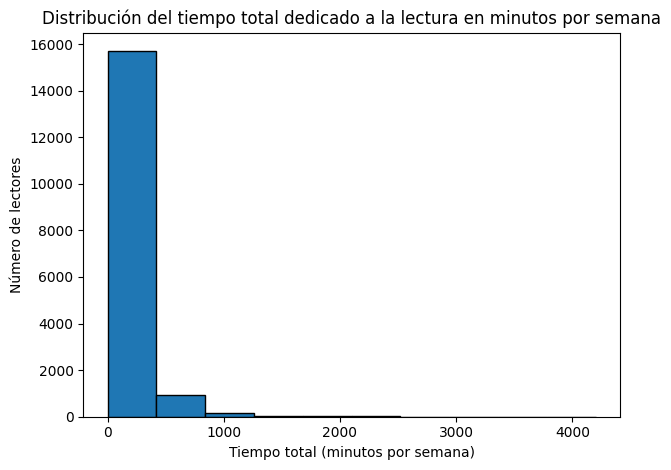

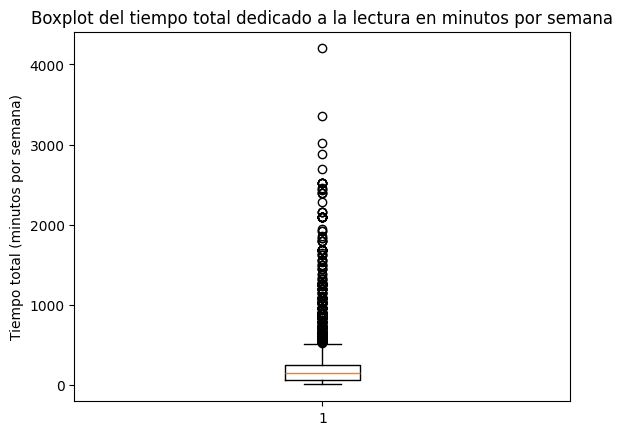

In [19]:
plt.hist(df_lectores['tiempo_total'], edgecolor='black')
plt.title('Distribución del tiempo total dedicado a la lectura en minutos por semana')
plt.xlabel('Tiempo total (minutos por semana)')
plt.ylabel('Número de lectores')
plt.tight_layout()
plt.show()

plt.boxplot(df_lectores['tiempo_total'])
plt.title('Boxplot del tiempo total dedicado a la lectura en minutos por semana')
plt.ylabel('Tiempo total (minutos por semana)')
plt.show()